<a href="https://colab.research.google.com/github/jahnavi1thoom/DeepLearning/blob/main/RNN(deep_learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn .preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

In [4]:
#load the dataset
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/My Drive/optimized_waste_management_data.csv'
data=pd.read_csv(path)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


# **handling missing data**

In [5]:
data.isnull().sum()

,0
date,0
waste_volume,0
organic_waste,0
recyclable_waste,0
hazardous_waste,0
collection_frequency,0
landfill_capacity_used,0
recycling_rate,0


In [7]:
#extract feature to predict
#we only use the waste column for forecasting
waste_data=data[['waste_volume']]

In [8]:
#normalize the data such that data values are scaled between 0 and 1
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)


# **Convert data into Sequences**

RNN requires sequential input.

ex:previous 10 days->predict next day

In [9]:
def create_sequences(data,seq_length):
  x=[]
  y=[]
  for i in range(len(data)-seq_length):
    x.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(x),np.array(y)

# **Create Time Sequences**

In [10]:
seq_length=10
x,y=create_sequences(scaled_data,seq_length)

#fit the shape
print(x.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


# **Build the RNN Model**

Architecture:

Input -> RNN layer -> Dense output

In [11]:
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(seq_length,1)))
#50 neurons
#tanh activation
#input shape=(10 time steps,1 feature)
model.add(Dense(1))#one val-> next day waste

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **compile the model**

In [13]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

# **split the data into training and testing**

In [14]:
split=int(0.8*len(x))
x_train=x[:split]
y_train=y[:split]
x_test=x[split:]
y_test=y[split:]

# **train the Model**

we train the model for 50 epochs

In [15]:
history=model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1

)
#model uses entire data 50 times as epochs=50
#16 samples per update as batch size=16
#10% is used for validation

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0548 - val_loss: 0.0162
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126 - val_loss: 0.0136
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0120 - val_loss: 0.0157
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0110 - val_loss: 0.0134
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0109 - val_loss: 0.0113
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0112
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0112
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0105 - val_loss: 0.0114
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0117
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0117
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0152
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_l

# **Evaluate the Model**

In [17]:
loss=model.evaluate(x_test,y_test)
print("trst loss:",loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0095
trst loss: 0.009499264881014824


# **Make predictions**

In [18]:
predictions=model.predict(x_test)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


# **Convert Predictions Back to Original Scale**

In [19]:
predictions=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test)


# **Plot Predictions vs Actual Values**

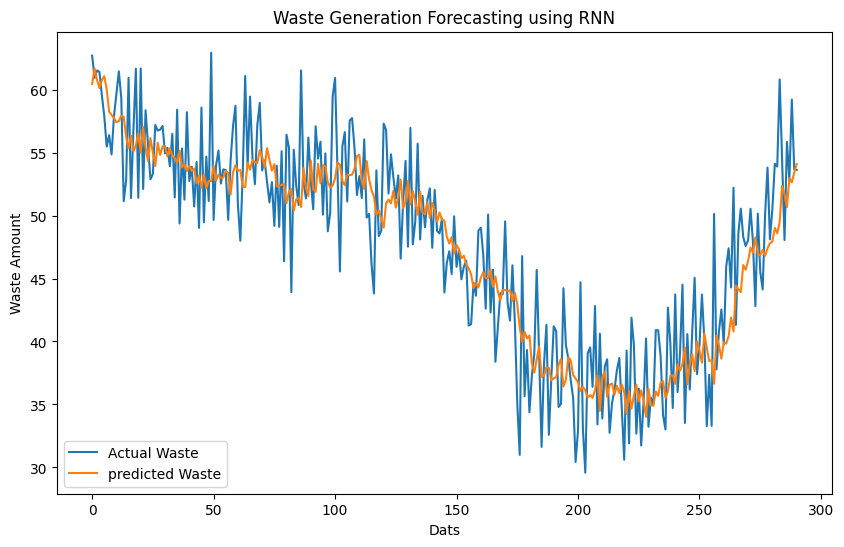

In [21]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual,label="Actual Waste")
plt.plot(predictions,label="predicted Waste")

plt.title("Waste Generation Forecasting using RNN")
plt.xlabel("Dats")
plt.ylabel("Waste Amount")
plt.legend()
plt.show()

# **IMDB dataset for classification type of data ie cateegorical**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/My Drive/IMDB_Dataset.csv'
data=pd.read_csv(path)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Students should explore the dataset.
Tasks:
Load the dataset
Check dataset size
Count positive vs negative reviews
Display sample reviews
Calculate average review length
Check:
Are reviews balanced?
Are reviews long or short?

In [6]:
data.shape

(50000, 2)

In [9]:
print(data['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [10]:
data['length'] = data['review'].apply(lambda x: len(x.split()))
print("Average length:", data['length'].mean())

Average length: 231.15694


Task 3 — Text Preprocessing

Raw text cannot be fed directly into neural networks.
You must perform preprocessing:
Tasks:
Convert text to lowercase
Remove punctuation
Remove HTML tags
Tokenize words
Remove stopwords
Convert words → sequences
Expected output example:
Original:
"This movie was absolutely fantastic!"
Processed:
["movie", "absolutely", "fantastic"

In [11]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# download once
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# 🔹 preprocessing function
def preprocess(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   #  important (new versions need this)
nltk.download('stopwords')
# apply preprocessing
data['tokens'] = data['review'].apply(preprocess)

# convert tokens back to text
data['clean_text'] = data['tokens'].apply(lambda x: " ".join(x))

# Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['clean_text'])

# text → sequences
sequences = tokenizer.texts_to_sequences(data['clean_text'])

# padding (same length)
X = pad_sequences(sequences, maxlen=100)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Task 4 — Tokenization and Vocabulary Building
You must convert words into numerical representations.
Tasks:
Use Keras Tokenizer
Create vocabulary
Convert reviews → sequences
Display word index mapping

Example:
Word	Index
movie	1
good	2
bad	3

Check:

Why neural networks cannot process raw text directly?



In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

# initialize tokenizer
tokenizer = Tokenizer(num_words=5000)   # top 5000 words
tokenizer.fit_on_texts(data['clean_text'])

In [18]:
word_index = tokenizer.word_index
print("Vocabulary size:", len(word_index))

Vocabulary size: 222320


In [19]:
sequences = tokenizer.texts_to_sequences(data['clean_text'])

# example
print(sequences[0])

[3, 1809, 940, 56, 398, 3216, 286, 349, 3027, 107, 481, 470, 19, 57, 3098, 3216, 50, 472, 180, 107, 548, 52, 1605, 41, 41, 2359, 1339, 276, 472, 3260, 246, 233, 353, 3216, 240, 2419, 938, 2483, 1246, 422, 4558, 2376, 1079, 2830, 298, 213, 4902, 3570, 422, 236, 4990, 2319, 224, 34, 126, 7, 45, 166, 1172, 41, 550, 91, 159, 154, 436, 2845, 703, 85, 1144, 4167, 2353, 974, 703, 1282, 703, 58, 852, 88, 19, 286, 43, 103, 3098, 1451, 2067, 288, 45, 1422, 174, 1336, 1121, 3216, 83, 213, 1949, 1961, 472, 472, 4784, 2799, 380, 499, 14, 140, 13, 632, 693, 542, 1079, 550, 438, 808, 1860, 1079, 443, 56, 3216, 98, 302, 3603, 3116, 14, 1082, 3863, 392]


In [20]:
# show first 10 words
for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

movie : 1
film : 2
one : 3
like : 4
good : 5
even : 6
would : 7
time : 8
really : 9
see : 10


Task 5 — Sequence Padding
RNN requires fixed-length input sequences.
Tasks:
Find maximum review length
Apply padding using pad_sequences()
Compare before and after padding
Example:
Before padding
[12, 45, 67]
After padding
[0,0,0,12,45,67]
You must explain:
Why padding is necessary for RNN models.




In [21]:
# find max length
max_len = max(len(seq) for seq in sequences)
print("Max length:", max_len)

Max length: 885


In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# apply padding
X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
print(X_padded[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [23]:
print("Before:", sequences[0])
print("After :", X_padded[0])

Before: [3, 1809, 940, 56, 398, 3216, 286, 349, 3027, 107, 481, 470, 19, 57, 3098, 3216, 50, 472, 180, 107, 548, 52, 1605, 41, 41, 2359, 1339, 276, 472, 3260, 246, 233, 353, 3216, 240, 2419, 938, 2483, 1246, 422, 4558, 2376, 1079, 2830, 298, 213, 4902, 3570, 422, 236, 4990, 2319, 224, 34, 126, 7, 45, 166, 1172, 41, 550, 91, 159, 154, 436, 2845, 703, 85, 1144, 4167, 2353, 974, 703, 1282, 703, 58, 852, 88, 19, 286, 43, 103, 3098, 1451, 2067, 288, 45, 1422, 174, 1336, 1121, 3216, 83, 213, 1949, 1961, 472, 472, 4784, 2799, 380, 499, 14, 140, 13, 632, 693, 542, 1079, 550, 438, 808, 1860, 1079, 443, 56, 3216, 98, 302, 3603, 3116, 14, 1082, 3863, 392]
After : [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0

Task 6 — Build an RNN Model
You must implement a simple RNN architecture.
Architecture example:
Embedding Layer
SimpleRNN Layer
Dense Layer
Output Layer
Tasks:
Define embedding layer
Add SimpleRNN layer
Add dense output layer
Compile model
Students must print:
model.summary()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [25]:
vocab_size = 5000     # same as tokenizer num_words
embedding_dim = 64
max_len = X_padded.shape[1]

In [26]:
model = Sequential()

# 1. Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))

# 2. Simple RNN Layer
model.add(SimpleRNN(64))

# 3. Dense Output Layer
model.add(Dense(1, activation='sigmoid'))   # binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Task 7 — Train the RNN Model
You must train the model.
Tasks:
Split dataset into train/test
Train the RNN model
Plot training accuracy
Plot validation accuracy
You must analyze:
Is the model overfitting?
Is accuracy improving?

In [35]:
y = data['sentiment']

In [36]:
print(data['sentiment'].unique())

['positive' 'negative']


In [38]:
y = data['sentiment'].map({'negative': 0, 'positive': 1})

In [39]:
y = data['sentiment']   # no change needed

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42
)

Task 8 — Evaluate Model Performance
You must evaluate the trained model.
Tasks:
Calculate accuracy
Generate confusion matrix
Compute precision and recall
Analyze misclassified reviews
You must interpret:
Which type of reviews are harder to classify?

In [43]:
data['sentiment'] = data['sentiment'].map({'negative': 0, 'positive': 1})

In [44]:
y = data['sentiment']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42
)

In [46]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [47]:
from sklearn.metrics import accuracy_score

y_pred = (model.predict(X_test) > 0.5).astype("int32")

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
Accuracy: 0.4997


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[2256 2705]
 [2298 2741]]


In [49]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.5033051781123761
Recall: 0.543957134352054


In [51]:
import numpy as np

misclassified = np.where(y_test != y_pred.flatten())[0]

for i in misclassified[:5]:   # show first 5
    print("Review:", data.iloc[i]['review'])
    print("Actual:", y_test.iloc[i], "Predicted:", y_pred[i][0])
    print("------")

Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

Task 9 — Real-Time Prediction System
You must build a custom review prediction function.
Example:
Input:
"This product quality is amazing"
Expected Output:
Predicted Sentiment → Positive
Confidence → 0.92
You must test at least 5 custom reviews.

In [52]:
def predict_review(text):
    # 1. Preprocess
    text = text.lower()

    # 2. Convert to sequence
    seq = tokenizer.texts_to_sequences([text])

    # 3. Padding
    padded = pad_sequences(seq, maxlen=X_padded.shape[1])

    # 4. Predict
    pred = model.predict(padded)[0][0]

    # 5. Convert to label
    sentiment = "Positive" if pred > 0.5 else "Negative"

    return sentiment, pred

In [53]:
reviews = [
    "This product quality is amazing",
    "Worst experience ever",
    "Not bad, but could be better",
    "Absolutely loved it",
    "Terrible and disappointing"
]

for r in reviews:
    sentiment, confidence = predict_review(r)
    print(f"Review: {r}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2f}")
    print("------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
Review: This product quality is amazing
Predicted Sentiment: Positive
Confidence: 0.50
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Review: Worst experience ever
Predicted Sentiment: Positive
Confidence: 0.53
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Review: Not bad, but could be better
Predicted Sentiment: Positive
Confidence: 0.52
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Review: Absolutely loved it
Predicted Sentiment: Positive
Confidence: 0.54
------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Review: Terrible and disappointing
Predicted Sentiment: Positive
Confidence: 0.53
------
